# Foraga Quantium - Data Analytics Job Simulation

## Name: Parabjot Chander

### Situation & Task: 
I am part of Quantium’s retail analytics team and have been approached by my client, the Category Manager for chips, who wants to better understand the types of customers who purchase chips and their purchasing behaviour within the region.

### Tasks Broken-down: 
Examine transaction data – look for inconsistencies, missing data across the data set, outliers, correctly identified category items, numeric data across all tables. If you determine any anomalies make the necessary changes in the dataset and save it. Having clean data will help when it comes to your analysis. 

Examine customer data – check for similar issues in the customer data, look for nulls and when you are happy merge the transaction and customer data together so it’s ready for the analysis ensuring you save your files along the way.

Data analysis and customer segments – in your analysis make sure you define the metrics – look at total sales, drivers of sales, where the highest sales are coming from etc. Explore the data, create charts and graphs as well as noting any interesting trends and/or insights you find. These will all form part of our report to Julia. 

Deep dive into customer segments – define your recommendation from your insights, determine which segments we should be targeting, if packet sizes are relative and form an overall conclusion based on your analysis. 

### Datasets:
QVI_purchase_behaviour.csv, QVI_transaction_data.xlsx

In [1]:
# installing libaries 
import numpy as np
import pandas as pd
import openpyxl

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("openpyxl version:",openpyxl.__version__)
#print("Hello World!")


NumPy version: 2.4.2
Pandas version: 3.0.1
openpyxl version: 3.1.5


In [2]:
pb_df = pd.read_csv("QVI_purchase_behaviour.csv")
pb_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [3]:
pb_df.dtypes

LYLTY_CARD_NBR      int64
LIFESTAGE             str
PREMIUM_CUSTOMER      str
dtype: object

In [4]:
td_df = pd.read_excel("QVI_transaction_data.xlsx", engine="openpyxl")
td_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
td_df.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME             str
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [6]:
# We can see that the date column is in an integer format. Let's change this to a
# date format.
td_df["DATE"] = pd.to_datetime(td_df['DATE'], unit='D',origin='1899-12-30')

td_df.dtypes

DATE              datetime64[s]
STORE_NBR                 int64
LYLTY_CARD_NBR            int64
TXN_ID                    int64
PROD_NBR                  int64
PROD_NAME                   str
PROD_QTY                  int64
TOT_SALES               float64
dtype: object

In [7]:
td_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
# Generate a summary of the PROD_NAME column
td_df['PROD_NAME'].describe()

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [9]:
# Data cleaning on the product_name column
# special characters
td_df['PROD_NAME'] = td_df['PROD_NAME'].str.replace(r'[^\w\s]', '', regex=True)

td_df.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly SCreamOnion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHnyJlpno Chili 150g,3,13.8
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,2018-08-18,7,7150,6900,52,Grain Waves Sour CreamChives 210G,2,7.2


In [10]:
"""
Let's look at the most common words by counting the number of times a word appears and
sorting them by this frequency in order of highest to lowest frequency
"""
td_df['PROD_NAME'].value_counts()

PROD_NAME
Kettle Mozzarella   Basil  Pesto 175g      3304
Kettle Tortilla ChpsHnyJlpno Chili 150g    3296
Cobs Popd SwtChlli SrCream Chips 110g      3269
Tyrrells Crisps     Ched  Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g             3265
                                           ... 
RRD Pc Sea Salt     165g                   1431
Woolworths Medium   Salsa 300g             1430
NCC Sour Cream     Garden Chives 175g      1419
French Fries Potato Chips 175g             1418
WW Crinkle Cut      Original 175g          1410
Name: count, Length: 114, dtype: int64

In [11]:
"""
There are salsa products in the dataset but we are only interested in the chips
category, so let's remove these.
Remove salsa products!
"""
td_df_ = td_df[~td_df['PROD_NAME'].str.contains('Salsa', case=False, na=False)]
td_df['PROD_NAME'].value_counts()

PROD_NAME
Kettle Mozzarella   Basil  Pesto 175g      3304
Kettle Tortilla ChpsHnyJlpno Chili 150g    3296
Cobs Popd SwtChlli SrCream Chips 110g      3269
Tyrrells Crisps     Ched  Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g             3265
                                           ... 
RRD Pc Sea Salt     165g                   1431
Woolworths Medium   Salsa 300g             1430
NCC Sour Cream     Garden Chives 175g      1419
French Fries Potato Chips 175g             1418
WW Crinkle Cut      Original 175g          1410
Name: count, Length: 114, dtype: int64

In [12]:
#Summarise the data to check for nulls and possible outliers
td_df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [13]:
td_df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [14]:
"""
There are no nulls in the columns but product quantity appears to have an outlier which we should investigate further. 
Let's investigate further the case where 200 packets of chips are bought in one transaction.
"""
outliers = td_df[td_df['PROD_QTY'] == 200.0]
print(outliers)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [15]:
customer = td_df[td_df['LYLTY_CARD_NBR'] == 226000]
print(customer)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [16]:
"""
It looks like this customer has only had the two transactions over the year and is not an ordinary retail customer. 
The customer might be buying chips for commercial purposes instead. We'll remove this loyalty card number from further analysis.
"""
td_df_clean = td_df[td_df['LYLTY_CARD_NBR'] != 226000]

td_df_clean.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264834,264834.000000,2.648340e+05,2.648340e+05,264834.000000,264834.000000,264834.000000
mean,2018-12-30 00:52:10,135.079423,1.355488e+05,1.351576e+05,56.583554,1.905813,7.299346
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760050e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351365e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.026998e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.784063,8.057990e+04,7.813292e+04,32.826444,0.343436,2.527241


In [17]:
""" That's better. Now, let's look at the number of transaction lines over time to see
if there are any obvious data issues such as missing data.
Count the number of transactions by date
"""
td_df_clean['DATE'].value_counts()

DATE
2018-12-24    939
2018-12-23    917
2018-12-22    915
2018-12-19    906
2018-12-18    862
             ... 
2018-12-12    664
2019-06-24    662
2019-06-13    659
2018-10-18    658
2018-11-25    648
Name: count, Length: 364, dtype: int64

In [18]:
""" 
There's only 364 rows, meaning only 364 dates which indicates a missing date. Let's
create a sequence of dates from 1 Jul 2018 to 30 Jun 2019 and use this to create a
chart of number of transactions over time to find the missing date.
"""


" \nThere's only 364 rows, meaning only 364 dates which indicates a missing date. Let's\ncreate a sequence of dates from 1 Jul 2018 to 30 Jun 2019 and use this to create a\nchart of number of transactions over time to find the missing date.\n"

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go 
from plotly.offline import iplot

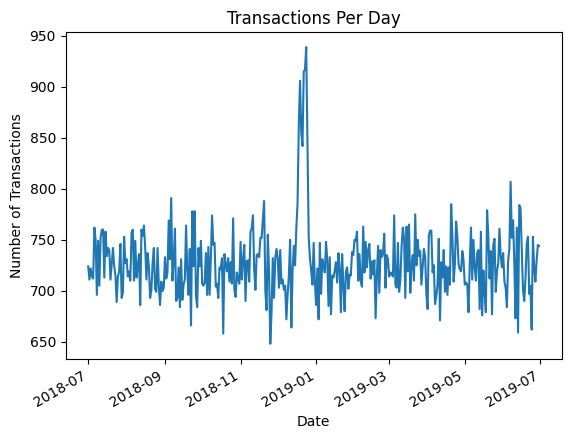

In [20]:
transactions_per_day = td_df_clean.groupby("DATE").size().sort_index()

transactions_per_day.plot()

plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Transactions Per Day")

plt.show()

We can see that there is an increase in purchases in December and a break in late December. Let's zoom in on this


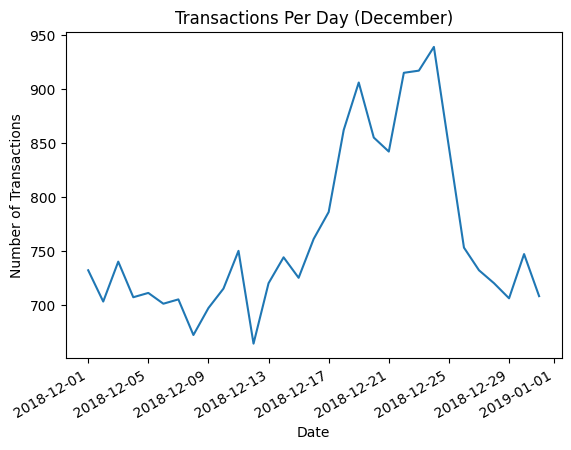

In [21]:
december_df = td_df_clean[td_df_clean["DATE"].dt.month == 12]
december_transactions = december_df.groupby("DATE").size().sort_index()
december_transactions.plot()

plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Transactions Per Day (December)")

plt.show()

We can see that the increase in sales occurs in the lead-up to Christmas and that there are zero sales on Christmas day itself. This is due to shops being closed on Christmas day.

In [22]:
december_transactions.head(-5)

DATE
2018-12-01    732
2018-12-02    703
2018-12-03    740
2018-12-04    707
2018-12-05    711
2018-12-06    701
2018-12-07    705
2018-12-08    672
2018-12-09    697
2018-12-10    715
2018-12-11    750
2018-12-12    664
2018-12-13    720
2018-12-14    744
2018-12-15    725
2018-12-16    761
2018-12-17    786
2018-12-18    862
2018-12-19    906
2018-12-20    855
2018-12-21    842
2018-12-22    915
2018-12-23    917
2018-12-24    939
2018-12-26    753
dtype: int64

We can move on to creating other features such as brand of chips or pack size from PROD_NAME. We will start with pack size.

In [23]:
#  We can work this out by extracting the digits that are in PROD_NAME
td_df_clean['PACK_SIZE'] = td_df_clean['PROD_NAME'].str.extract(r'(\d+)')
td_df_clean['PACK_SIZE'].head()

0    175
1    175
2    170
3    175
4    150
Name: PACK_SIZE, dtype: str

In [24]:
td_df_clean.dtypes

DATE              datetime64[s]
STORE_NBR                 int64
LYLTY_CARD_NBR            int64
TXN_ID                    int64
PROD_NBR                  int64
PROD_NAME                   str
PROD_QTY                  int64
TOT_SALES               float64
PACK_SIZE                   str
dtype: object

In [25]:
td_df_clean['PACK_SIZE'] = td_df_clean['PACK_SIZE'].astype('int64')
td_df_clean['PACK_SIZE'].dtype

dtype('int64')

In [26]:
td_df_clean['PACK_SIZE'].describe()

count    264834.000000
mean        182.425512
std          64.325148
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

####  Let's plot a histogram of PACK_SIZE since we know that it is a categorical variable and not a continuous variable even though it is numeric

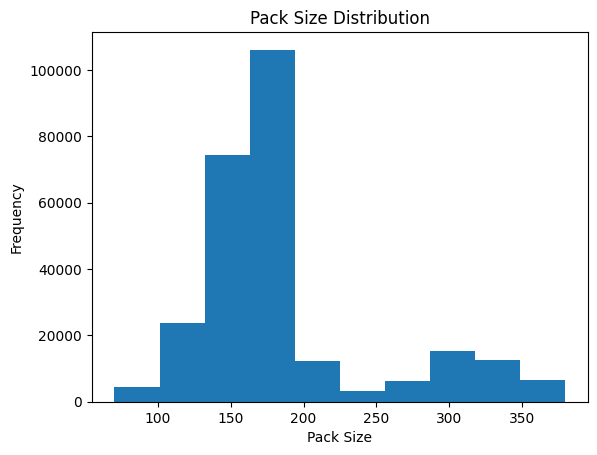

In [27]:
plt.hist(td_df_clean['PACK_SIZE'])
plt.xlabel("Pack Size")
plt.ylabel("Frequency")
plt.title("Pack Size Distribution")

plt.show()

Pack sizes created look reasonable. 
Now to create brands, we can use the first word in PROD_NAME to work out the brand 
name

In [28]:
td_df_clean['PROD_BRAND'] = td_df_clean['PROD_NAME'].str.extract(r'^(\S+)')
td_df_clean["PROD_BRAND"].unique()

<StringArray>
[   'Natural',        'CCs',     'Smiths',     'Kettle',        'Old',
      'Grain',    'Doritos',   'Twisties',         'WW',      'Thins',
     'Burger',        'NCC',   'Cheezels',     'Infzns',        'Red',
   'Pringles',     'Dorito',  'Infuzions',      'Smith',    'GrnWves',
   'Tyrrells',       'Cobs', 'Woolworths',     'French',        'RRD',
   'Tostitos',    'Cheetos',      'Snbts',   'Sunbites']
Length: 29, dtype: str

In [29]:
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'RRD', 'PROD_BRAND'] = 'Red'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'WW', 'PROD_BRAND'] = 'Woolworths'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'Snbts', 'PROD_BRAND'] = 'Sunbites'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'NCC', 'PROD_BRAND'] = 'Natural'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'Dorito', 'PROD_BRAND'] = 'Doritos'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'GrnWves', 'PROD_BRAND'] = 'Grain'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'Smith', 'PROD_BRAND'] = 'Smiths'
td_df_clean.loc[td_df_clean['PROD_BRAND'] == 'Infzns', 'PROD_BRAND'] = 'Infuzions'


td_df_clean['PROD_BRAND'].unique()

<StringArray>
[   'Natural',        'CCs',     'Smiths',     'Kettle',        'Old',
      'Grain',    'Doritos',   'Twisties', 'Woolworths',      'Thins',
     'Burger',   'Cheezels',  'Infuzions',        'Red',   'Pringles',
   'Tyrrells',       'Cobs',     'French',   'Tostitos',    'Cheetos',
   'Sunbites']
Length: 21, dtype: str

### Examining customer data
Now that we are happy with the transaction dataset, let's have a look at the 
customer dataset. We will do some basic summaries of the dataset, including distributions of 
any key columns.

In [30]:
pb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [31]:
pb_df.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [32]:
pb_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [33]:
pb_df.shape

(72637, 3)

In [34]:
pb_df['LYLTY_CARD_NBR'].unique().sum()

np.int64(9892137526)

In [35]:
pb_df.dtypes

LYLTY_CARD_NBR      int64
LIFESTAGE             str
PREMIUM_CUSTOMER      str
dtype: object

In [36]:
pb_df['LIFESTAGE'].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [37]:
pb_df['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [38]:
pb_df.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [39]:
pb_df.dtypes

LYLTY_CARD_NBR      int64
LIFESTAGE             str
PREMIUM_CUSTOMER      str
dtype: object

In [40]:
td_df_clean.dtypes

DATE              datetime64[s]
STORE_NBR                 int64
LYLTY_CARD_NBR            int64
TXN_ID                    int64
PROD_NBR                  int64
PROD_NAME                   str
PROD_QTY                  int64
TOT_SALES               float64
PACK_SIZE                 int64
PROD_BRAND                  str
dtype: object

#### Merge transaction data to customer data

In [41]:
merged_df = pd.merge(td_df_clean, pb_df, on="LYLTY_CARD_NBR", how="left")
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,PROD_BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly SCreamOnion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHnyJlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [42]:
merged_df.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
PROD_BRAND          0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [43]:
"""
When we continue with Task 2, we will retain this dataset which you can write out as a csv QVI_data.csv
"""
merged_df.to_csv("QVI_data.csv")

In [44]:
merged_df.dtypes

DATE                datetime64[s]
STORE_NBR                   int64
LYLTY_CARD_NBR              int64
TXN_ID                      int64
PROD_NBR                    int64
PROD_NAME                     str
PROD_QTY                    int64
TOT_SALES                 float64
PACK_SIZE                   int64
PROD_BRAND                    str
LIFESTAGE                     str
PREMIUM_CUSTOMER              str
dtype: object

In [45]:
merged_df['LIFESTAGE'].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48594
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

### Data analysis on customer segments
#### Now that the data is ready for analysis, we can define some metrics of interest to the client:
• Who spends the most on chips (totalsales), describing customers by lifestage and how premium their general purchasing behaviour is \
• How many customers are in each segment\
• How many chips are bought per customer by segment\
• What’s the average chip price by customer segment\

#### Total sales by LIFESTAGE and PREMIUM_CUSTOMER

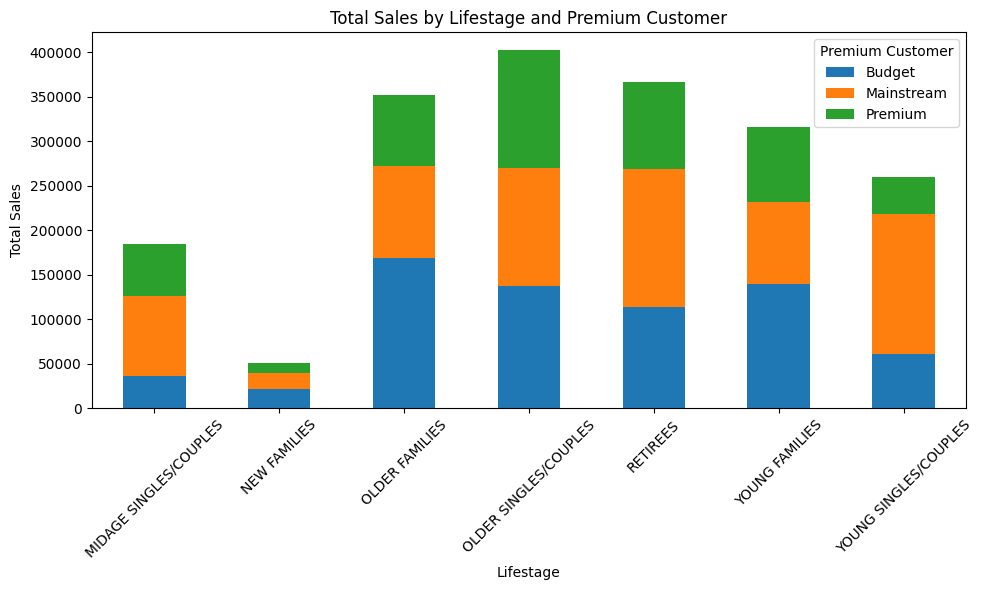

In [46]:

# Aggregate total sales 
grouped = (
    merged_df
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES']
    .sum()
    .reset_index()
)

# Pivot for stacking
pivot_df = grouped.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='TOT_SALES'
).fillna(0)

# Plot stacked bar chart
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Total Sales by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")
plt.tight_layout()

plt.show()

Sales are coming mainly from Budget - older families, Mainstream - young 
singles/couples, and Mainstream - retirees
Let's see if the higher sales are due to there being more customers who buy chips.

#### Number of customers by LIFESTAGE and PREMIUM_CUSTOMER

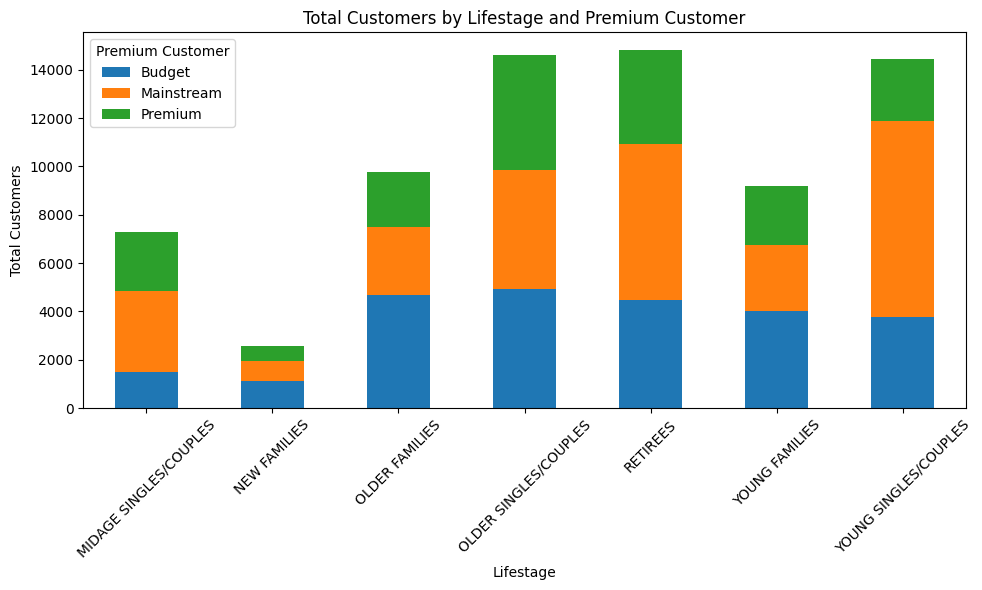

In [47]:
# Aggregate total sales 
grouped = (
    merged_df
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
    .nunique()
    .reset_index(name='UNIQUE_CUSTOMERS')
)

# Pivot for stacking
pivot_df = grouped.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='UNIQUE_CUSTOMERS'
).fillna(0)

# Plot stacked bar chart
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Total Customers by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Total Customers")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")
plt.tight_layout()

plt.show()

There are more Mainstream - young singles/couples and Mainstream - retirees who buy
chips. This contributes to there being more sales to these customer segments but 
this is not a major driver for the Budget - Older families segment.
Higher sales may also be driven by more units of chips being bought per customer. 
Let's have a look at this next.

#### Average number of units per customer by LIFESTAGE and PREMIUM_CUSTOMER

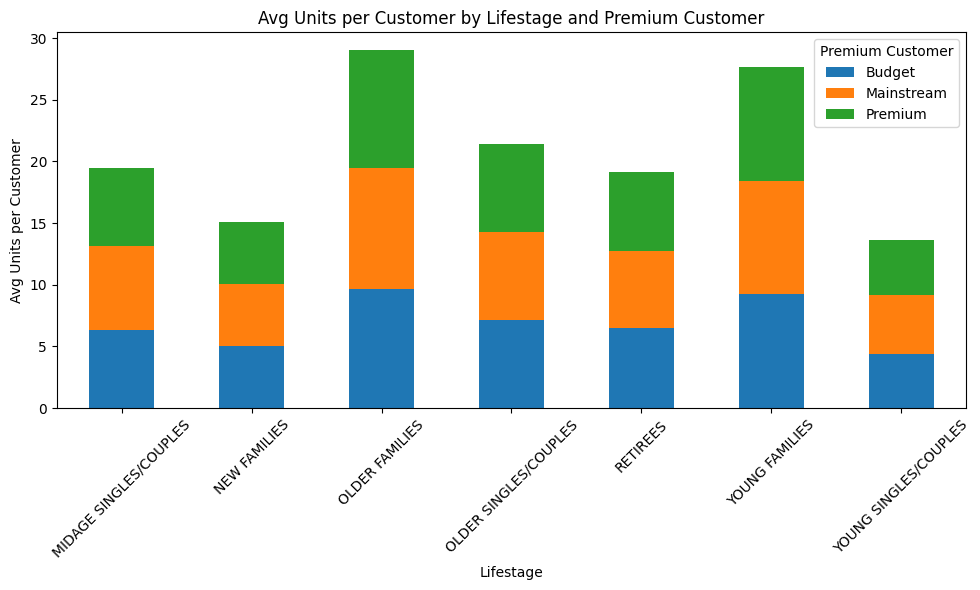

In [48]:
# Aggregate both pieces
grouped = (
    merged_df
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        TOTAL_QTY=('PROD_QTY', 'sum'),
        UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
    )
    .reset_index()
)

# Create a metric
grouped['AVG_UNITS_PER_CUSTOMER'] = (
    grouped['TOTAL_QTY'] / grouped['UNIQUE_CUSTOMERS']
)

# Pivot for stacked bar chart
pivot_df = grouped.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='AVG_UNITS_PER_CUSTOMER'
).fillna(0)

# plot stacked bar graph
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Avg Units per Customer by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Avg Units per Customer")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")
plt.tight_layout()

plt.show()

Older families and young families in general buy more chips per customer
Let's also investigate the average price per unit chips bought for each customer 
segment as this is also a driver of total sales.

#### Average price per unit by LIFESTAGE and PREMIUM_CUSTOMER

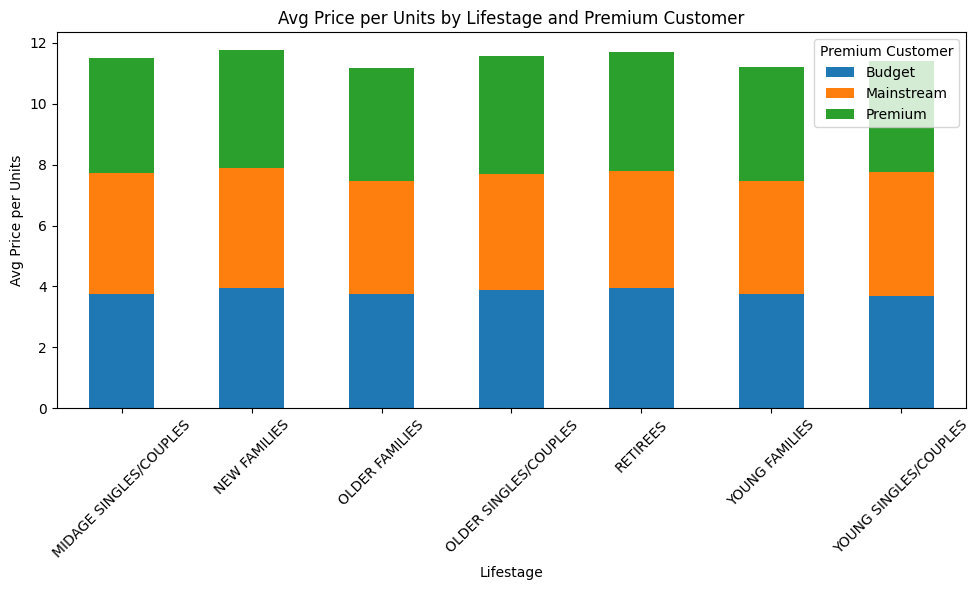

In [49]:
# Aggregate both pieces
grouped = (
    merged_df
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        TOTAL_QTY=('PROD_QTY', 'sum'),
        TOTAL_SALES=('TOT_SALES', 'sum')
    )
    .reset_index()
)

# Create a metric
grouped['AVG_PRICE_PER_UNITS'] = (
    grouped['TOTAL_SALES'] / grouped['TOTAL_QTY']
)

# Pivot for stacked bar chart
pivot_df = grouped.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='AVG_PRICE_PER_UNITS'
).fillna(0)

# plot stacked bar graph
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Avg Price per Units by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Avg Price per Units")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")
plt.tight_layout()

plt.show()

Mainstream midage and young singles and couples are more willing to pay more per 
packet of chips compared to their budget and premium counterparts. This may be due 
to premium shoppers being more likely to buy healthy snacks and when they buy 
chips, this is mainly for entertainment purposes rather than their own consumption.
This is also supported by there being fewer premium midage and young singles and 
couples buying chips compared to their mainstream counterparts.
As the difference in average price per unit isn't large, we can check if this difference is statistically different.

#### Perform a t-test to see if the difference is significant

In [50]:
from scipy import stats

# 1. Create the price per unit column
merged_df['price'] = merged_df['TOT_SALES'] / merged_df['PROD_QTY']

# 2. Define the lifestage filter
lifestages = ["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"]

# 3. Filter the two groups
# Group 1: Mainstream customers in the specified lifestages
group_mainstream = merged_df[
    (merged_df['LIFESTAGE'].isin(lifestages)) & 
    (merged_df['PREMIUM_CUSTOMER'] == "Mainstream")
]['price']

# Group 2: Non-Mainstream customers in the same lifestages
group_others = merged_df[
    (merged_df['LIFESTAGE'].isin(lifestages)) & 
    (merged_df['PREMIUM_CUSTOMER'] != "Mainstream")
]['price']

# 4. Perform the Independent T-Test (Welch's T-test if variances differ)
t_stat, p_val = stats.ttest_ind(group_mainstream, group_others, alternative='greater')

print(f"T-statistic: {t_stat}, P-value: {p_val}")


T-statistic: 40.8341367879116, P-value: 0.0


The t-test results in a p-value of 40.8341367879116, i.e. the unit price for mainstream, 
young and mid-age singles and couples ARE significantly higher than 
that of budget or premium, young and midage singles and couples.

We might want to target customer segments that contribute the most to sales to retain them or further increase sales. Let’s look at Mainstream - young singles/couples. For instance, let’s find out if they tend to buy a particular brand of chips.

In [54]:
# 1. Define the target segment mask
mask = (merged_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream')

# 2. Split the data
segment1 = merged_df[mask]
other = merged_df[~mask]

# 3. Calculate total quantities for normalization
quantity_segment1 = segment1['PROD_QTY'].sum()
quantity_other = other['PROD_QTY'].sum()

# 4. Calculate Brand Proportions for Segment 1
target_brand_prop = segment1.groupby('PROD_BRAND')['PROD_QTY'].sum().reset_index()
target_brand_prop['targetSegment'] = target_brand_prop['PROD_QTY'] / quantity_segment1

# 5. Calculate Brand Proportions for 'Other'
other_brand_prop = other.groupby('PROD_BRAND')['PROD_QTY'].sum().reset_index()
other_brand_prop['other'] = other_brand_prop['PROD_QTY'] / quantity_other

# 6. Merge and calculate affinity
brand_proportions = pd.merge(
    target_brand_prop[['PROD_BRAND', 'targetSegment']], 
    other_brand_prop[['PROD_BRAND', 'other']], 
    on='PROD_BRAND'
)

brand_proportions['affinityToBrand'] = brand_proportions['targetSegment'] / brand_proportions['other']

# 7. Sort by affinity (descending)
brand_proportions = brand_proportions.sort_values(by='affinityToBrand', ascending=False)
brand_proportions

,PROD_BRAND,targetSegment,other,affinityToBrand
19,Tyrrells,0.029587,0.023933,1.236235
18,Twisties,0.043306,0.035283,1.227401
9,Kettle,0.185649,0.154216,1.203823
17,Tostitos,0.042581,0.035377,1.203638
11,Old,0.041598,0.034753,1.196958
12,Pringles,0.111980,0.093743,1.194536
5,Doritos,0.122877,0.105277,1.167176
4,Cobs,0.041856,0.036375,1.150700
8,Infuzions,0.060649,0.053157,1.140947
16,Thins,0.056611,0.053084,1.066445


• Mainstream young singles/couples are 23% more likely to purchase Tyrrells chips compared to the rest of the population \
• Mainstreamyoungsingles/couples are 56% less likely to purchase Burger Rings compared to the rest of the population

Let’s also find out if our target segment tends to buy larger packs of chips.

In [56]:
# 1. Calculate Pack Proportions for Segment 1
target_pack_prop = segment1.groupby('PACK_SIZE')['PROD_QTY'].sum().reset_index()
target_pack_prop['targetSegment'] = target_pack_prop['PROD_QTY'] / quantity_segment1

# 2. Calculate Pack Proportions for 'Other'
other_pack_prop = other.groupby('PACK_SIZE')['PROD_QTY'].sum().reset_index()
other_pack_prop['other'] = other_pack_prop['PROD_QTY'] / quantity_other

# 3. Merge and calculate affinity
pack_proportions = pd.merge(
    target_pack_prop[['PACK_SIZE', 'targetSegment']], 
    other_pack_prop[['PACK_SIZE', 'other']], 
    on='PACK_SIZE'
)

pack_proportions['affinityToPack'] = pack_proportions['targetSegment'] / pack_proportions['other']

# 4. Sort by affinity (descending)
pack_proportions = pack_proportions.sort_values(by='affinityToPack', ascending=False)
pack_proportions

,PACK_SIZE,targetSegment,other,affinityToPack
17,270,0.029846,0.023377,1.276694
20,380,0.030156,0.023832,1.265361
19,330,0.057465,0.046727,1.229814
4,134,0.111980,0.093743,1.194536
2,110,0.099658,0.083642,1.191482
14,210,0.027309,0.023401,1.167002
5,135,0.013849,0.012180,1.136997
16,250,0.013460,0.011905,1.130611
9,170,0.075740,0.075440,1.003980
18,300,0.054954,0.057263,0.959679


It looks like Mainstream young singles/couples are 27% more likely to purchase a 270g pack of chips compared to the rest of the population but let’s dive into what brands sell this pack size.

In [62]:
merged_df.loc[merged_df['PACK_SIZE'] == 270, 'PROD_NAME'].unique()

<StringArray>
['Twisties Cheese     270g', 'Twisties Chicken270g']
Length: 2, dtype: str

Twisties are the only brand offering 270g packs and so this may instead be reflecting a higher likelihood of purchasing Twisties.

### Conclusion

Sales have mainly been due to Budget - older families, Mainstream - young singles/couples, and Mainstream - retirees shoppers. We found that the high spend in chips for mainstream young singles/couples and re- tirees is due to there being more of them than other buyers. Mainstream, midage and young singles and couples are also more likely to pay more per packet of chips. This is indicative of impulse buying behaviour. We’ve also found that Mainstream young singles and couples are 23% more likely to purchase Tyrrells chips compared to the rest of the population. The Category Manager may want to increase the category’s per- formance by off-locating some Tyrrells and smaller packs of chips in discretionary space near segments where young singles and couples frequent more often to increase visibilty and impulse behaviour.
Quantium can help the Category Manager with recommendations of where these segments are and further help them with measuring the impact of the changed placement. We’ll work on measuring the impact of trials in the next task and putting all these together in the third task.